In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

sys.path.append("../src")

from data_loader import download_all_assets
from preprocessing import clean_all_data
from feature_engineering import add_features_all
from stats_analysis import summary_statistics_all,detect_outliers,adf_test
from visualization import plot_closing_prices
from risk_metrics import calculate_metrics_all


'''from statistics import (
    summary_statistics,
    adf_test,
    detect_outliers
)'''
'''from risk_metrics import (
    calculate_var,
    calculate_sharpe_ratio
)'''
'''from visualization import (
    plot_closing_prices,
    plot_daily_returns,
    plot_rolling_volatility)'''

'from visualization import (\n    plot_closing_prices,\n    plot_daily_returns,\n    plot_rolling_volatility)'

In [15]:
assets = download_all_assets()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [16]:
assets.keys()

dict_keys(['TSLA', 'BND', 'SPY'])

In [17]:
for ticker, df in assets.items():

    print("="*60)

    print(ticker)

    display(df.head())

TSLA


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,,
2015-01-02,14.620667,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333,51637500


BND


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BND,BND,BND,BND,BND,BND
Date,,,,,,
2015-01-02,59.205650,82.650002,82.690002,82.419998,82.430000,2218800
2015-01-05,59.377544,82.889999,82.919998,82.699997,82.739998,5820100
2015-01-06,59.549519,83.129997,83.379997,83.029999,83.029999,3887600
2015-01-07,59.585335,83.180000,83.279999,83.050003,83.139999,2433400
2015-01-08,59.492188,83.050003,83.110001,82.970001,83.110001,1873400


SPY


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2015-01-02,169.687820,205.429993,206.880005,204.179993,206.380005,121465900
2015-01-05,166.623383,201.720001,204.369995,201.350006,204.169998,169632600
2015-01-06,165.053970,199.820007,202.720001,198.860001,202.089996,209151400
2015-01-07,167.110733,202.309998,202.720001,200.880005,201.419998,125346700
2015-01-08,170.076096,205.899994,206.160004,203.990005,204.009995,147217800


In [18]:
assets = clean_all_data(assets)

In [19]:
assets = add_features_all(assets)

In [20]:
stats = summary_statistics_all(assets)

stats["TSLA"]

Price,Adj Close,Close,High,Low,Open,Volume,Daily_Return
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA,
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03,2887.000000
mean,148.773923,148.773923,151.990563,145.416731,148.797341,1.087922e+08,0.001803
std,138.895957,138.895957,141.852818,135.867193,138.977191,7.082549e+07,0.036018
min,9.578000,9.578000,10.331333,9.403333,9.488000,1.062000e+07,-0.210628
25%,18.393499,18.393499,18.665168,18.023666,18.390833,6.548325e+07,-0.016643
50%,133.437668,133.437668,136.053329,125.831669,131.496330,9.033615e+07,0.001216
75%,251.925831,251.925831,257.485008,245.832500,251.680004,1.261204e+08,0.019456
max,489.880005,489.880005,498.829987,485.329987,489.880005,9.140820e+08,0.226900


In [21]:
stats["BND"]

Price,Adj Close,Close,High,Low,Open,Volume,Daily_Return
Ticker,BND,BND,BND,BND,BND,BND,
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03,2887.000000
mean,66.281145,79.327722,79.442119,79.211198,79.330661,4.653786e+06,-0.000034
std,4.700143,5.310424,5.298010,5.322546,5.313805,3.017704e+06,0.003383
min,58.531746,68.040001,68.379997,67.989998,68.080002,0.000000e+00,-0.054385
25%,62.268031,73.800003,73.919998,73.639999,73.800003,2.233700e+06,-0.001635
50%,65.507381,80.814999,80.905003,80.709999,80.800003,4.280650e+06,0.000119
75%,70.451437,83.440002,83.550003,83.332500,83.470001,6.246475e+06,0.001715
max,74.581284,89.480003,89.589996,89.440002,89.550003,3.396300e+07,0.042201


In [22]:
stats["SPY"]

Price,Adj Close,Close,High,Low,Open,Volume,Daily_Return
Ticker,SPY,SPY,SPY,SPY,SPY,SPY,
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03,2887.000000
mean,351.505532,375.216714,377.167216,372.946586,375.149543,8.551049e+07,0.000507
std,155.443935,146.584697,147.244714,145.774814,146.558911,4.338553e+07,0.011163
min,154.161606,182.860001,184.100006,181.020004,182.339996,2.027000e+07,-0.109424
25%,223.546810,254.559998,255.919998,252.477497,254.577503,5.836455e+07,-0.003772
50%,312.817886,339.435013,342.315002,337.165009,339.835007,7.541950e+07,0.000603
75%,432.806839,453.677498,456.000000,451.549988,453.989990,9.882245e+07,0.005920
max,757.618225,759.570007,760.400024,756.750000,758.150024,5.072443e+08,0.105019


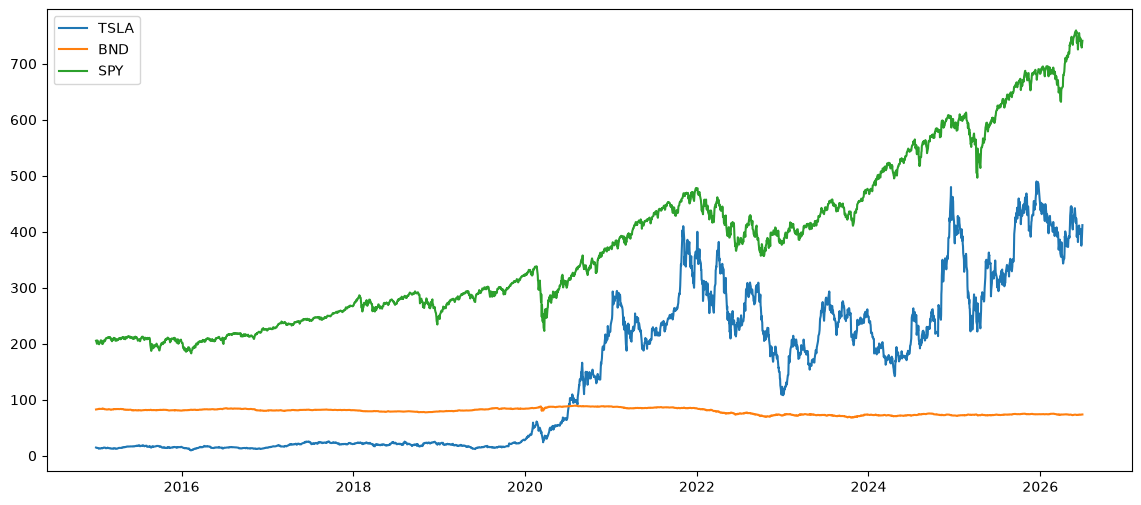

In [23]:
plot_closing_prices(assets)

In [24]:
risk_stats = calculate_metrics_all(assets)
print(risk_stats)

{'TSLA': {'VaR': np.float64(-0.051663755152845575), 'Sharpe': np.float64(0.7944370048126023)}, 'BND': {'VaR': np.float64(-0.005084862828803238), 'Sharpe': np.float64(-0.1591853661852481)}, 'SPY': {'VaR': np.float64(-0.016740570438910946), 'Sharpe': np.float64(0.7208920870756385)}}


In [25]:
detect_outliers(assets["TSLA"])

Price,Adj Close,Close,High,Low,Open,Volume,Daily_Return
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA,
Date,,,,,,,
2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000,93928500,0.005664
2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333,44526000,-0.001562
2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333,51637500,-0.001564
2015-01-09,13.777333,13.777333,13.998667,13.664000,13.928000,70024500,-0.018802
2015-01-12,13.480667,13.480667,13.631333,13.283333,13.536667,89254500,-0.021533
...,...,...,...,...,...,...,...
2026-06-22,405.049988,405.049988,414.750000,394.399994,394.850006,47819500,0.011386
2026-06-24,375.529999,375.529999,384.579987,373.049988,380.079987,37081400,-0.015932


In [26]:
adf_test(assets["TSLA"]["Close"])

{'ADF Statistic': np.float64(-1.0695991394177442),
 'p-value': np.float64(0.7270419411549228),
 'Stationary': np.False_}

In [27]:
calculate_var(features["TSLA"])



calculate_sharpe_ratio(features["TSLA"])

NameError: name 'calculate_var' is not defined

In [ ]:
from src.preprocessing import save_processed_data

save_processed_data(features)